In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp')

import cloudpickle
import torch
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.crn_text_parser import reactions_from_text

import sys
sys.path.append('../..')


First Run

## Solver & Setup

In [2]:
solver = 'CVODE'
ATOL = 1e-10
RTOL = 1e-10

checkpoint_path = Path(
    "/local0/home/mfilo/git/GenAI-Net/apps/"
    "Quadratic_task_chkpt_run_Quad_8S_16R-11.pkl"
)
hof_index = 0

# A compact grid for inputs for testing. Keep a > 0 because the formula divides by a.
a_values = np.array([0.1, 0.4, 0.7, 1.0], dtype=float)
b_values = np.linspace(0.0, 1.0, 11)
c_values = np.linspace(0.0, 1.0, 11)

## Evaluation Helpers


In [3]:
def quadratic_root(a, b, c):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    c = np.asarray(c, dtype=float)
    return (b + np.sqrt(b**2 + 4.0 * a * c)) / (2.0 * a)


def quadratic_residual(a, b, c, x):
    return a * x**2 - b * x - c


def make_input_grid(a_values, b_values, c_values):
    return [
        np.array([a, b, c], dtype=np.float32)
        for a in a_values
        for b in b_values
        for c in c_values
    ]


def make_random_inputs(n=300, a_range=(0.1, 1.0), b_range=(0.0, 1.0), c_range=(0.0, 1.0), seed=0):
    rng = np.random.default_rng(seed)
    a = rng.uniform(*a_range, size=n)
    b = rng.uniform(*b_range, size=n)
    c = rng.uniform(*c_range, size=n)
    return [np.array(u, dtype=np.float32) for u in np.column_stack([a, b, c])]


def evaluate_crn(crn, u_list, *, t_f=100.0, n_t=1000, ic_value=0.01, large_number=1e4):
    time_horizon = np.linspace(0.0, float(t_f), int(n_t), dtype=np.float32)
    x0 = np.full(crn.num_species, float(ic_value), dtype=np.float32)

    time, states, outputs, _ = crn.transient_response(
        u_list,
        [x0],
        time_horizon,
        LARGE_NUMBER=large_number,
        force=True,
    )

    rows = []
    for u, y in zip(u_list, outputs):
        a, b, c = [float(v) for v in np.asarray(u).reshape(-1)]
        x_pred = float(np.asarray(y)[0, -1])
        x_true = float(quadratic_root(a, b, c))
        abs_error = abs(x_pred - x_true)
        rel_error = abs_error / (abs(x_true) + 1e-12)
        residual = float(quadratic_residual(a, b, c, x_pred))
        rows.append({
            "a": a,
            "b": b,
            "c": c,
            "x_true": x_true,
            "x_pred": x_pred,
            "abs_error": abs_error,
            "rel_error": rel_error,
            "residual": residual,
            "abs_residual": abs(residual),
        })

    return pd.DataFrame(rows), states, outputs, time



## Load CRN

In [4]:
# Needed if the checkpoint was saved on GPU but loaded on CPU.
_original_torch_load = torch.load

def torch_load_cpu(*args, **kwargs):
    kwargs.setdefault("map_location", torch.device("cpu"))
    return _original_torch_load(*args, **kwargs)

torch.load = torch_load_cpu

with open(checkpoint_path, "rb") as f:
    checkpoint = cloudpickle.load(f)

hof = checkpoint["hall_of_fame_crns"]

# Hall of fame CRN, exactly as stored during training.
iocrn = hof[hof_index].clone()

print("Checkpoint epoch:", checkpoint["epoch"])
print("Hall of fame index:", hof_index)
print("Stored reward:", iocrn.last_task_info["reward"])
print(iocrn)
iocrn.reset()
iocrn.solver = solver
iocrn.atol = ATOL
iocrn.rtol = RTOL


Checkpoint epoch: 601
Hall of fame index: 0
Stored reward: 0.025822538819955464
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6', 'X_7', 'X_8'] 
Output Species: ['X_8'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_1 ----> X_7;  [MAK(0.38203567266464233)]
X_1 + X_8 ----> X_1 + X_3;  [MAK(0.28468623757362366)]
X_1 + X_8 ----> X_1 + X_5;  [MAK(0.35724663734436035)]
X_2 + X_2 ----> X_6 + X_8;  [MAK(0.3671592175960541)]
X_2 + X_5 ----> X_6 + X_7;  [MAK(0.5606043338775635)]
X_2 + X_6 ----> X_5 + X_8;  [MAK(0.34964635968208313)]
X_2 + X_8 ----> X_8 + X_8;  [MAK(0.6335757970809937)]
X_3 + X_3 ----> X_5 + X_6;  [MAK(0.311862587928772)]
X_3 + X_5 ----> X_8;  [MAK(0.35515275597572327)]
X_3 + X_7 ----> X_8;  [MAK(0.26504817605018616)]
X_3 + X_7 ----> X_3 + X_6;  [MAK(0.4871312379837036)]
X_4 + X_5 ----> X_5 + X_5;  [MAK(0.3621551990509033)]
X_5 + X_5 ----> X_4;  [MAK(0.43033134937286377)]
X_6 + X_6 ----> X_6 + X_8;  [

## Build I/O CRN

In [5]:
# reactions = [
#     MassAction([], ["X_1"], input_channels=["u_1"], params=[1.0], params_controllability=[False]),
#     MassAction(["X_1"], ["X_4", "X_4"], params=[0.04084748402237892]),
#     MassAction(["X_4"], ["X_1"], params=[0.04595428705215454]),
#     MassAction(["X_1", "X_1"], ["X_3", "X_4"], params=[0.048695046454668045]),
#     MassAction(["X_1", "X_2"], ["X_2"], params=[0.6668475270271301]),
#     MassAction(["X_1", "X_4"], ["X_2", "X_3"], params=[0.04605919495224953]),
#     MassAction(["X_2", "X_2"], [], params=[0.05097213387489319]),
#     MassAction(["X_3", "X_4"], ["X_1"], params=[0.05004750192165375]),
#     MassAction(["X_4", "X_4"], ["X_2", "X_4"], params=[0.04662628099322319]),
# ]

# reaction_text = """
# CRN hof_0, Reward: 0.3540686654368851 
# Inputs: ['u_1', 'u_2', 'u_3'] 
# Species: ['X_1', 'X_2', 'X_3', 'X_4', 'X_5'] 
# Output Species: ['X_5'] 
# ∅ ----> X_1;  [MAK(1.0, u_1)]
# ∅ ----> X_2;  [MAK(1.0, u_2)]
# ∅ ----> X_3;  [MAK(1.0, u_3)]
# X_1 ----> X_2;  [MAK(2.9613287448883057)]
# X_2 ----> X_3 + X_4;  [MAK(5.357151508331299)]
# X_2 ----> X_3 + X_5;  [MAK(3.287686824798584)]
# X_1 + X_5 ----> ∅;  [MAK(5.089560031890869)]
# X_2 + X_5 ----> X_5;  [MAK(2.019566297531128)]
# X_3 + X_3 ----> X_1 + X_5;  [MAK(5.154646873474121)]
# """

# reactions = reactions_from_text(reaction_text)

# iocrn = IOCRN(reactions, output_labels=['X_5'], solver=solver, atol=ATOL, rtol=RTOL)
# iocrn.compile()
# iocrn.solver = solver
# iocrn.atol = ATOL
# iocrn.rtol = RTOL
# print(iocrn)

## Generate Inputs

In [6]:
grid_inputs = make_input_grid(a_values, b_values, c_values)
random_inputs = make_random_inputs(n=300, seed=1)

print("grid inputs:", len(grid_inputs))
print("random inputs:", len(random_inputs))

grid inputs: 484
random inputs: 300


## Simulate

In [7]:
df_grid, x_grid, y_grid, t_grid = evaluate_crn(iocrn, grid_inputs, t_f=1000.0, n_t=1000, ic_value=0.01)
df_random, x_random, y_random, t_random = evaluate_crn(iocrn, random_inputs, t_f=1000.0, n_t=1000, ic_value=0.01)

display(df_grid.head())
display(df_random[["abs_error", "rel_error", "abs_residual"]].describe())


,a,b,c,x_true,x_pred,abs_error,rel_error,residual,abs_residual
0,0.1,0.0,0.0,0.000000,7.429957e-12,7.429957e-12,7.429957,5.520426e-24,5.520426e-24
1,0.1,0.0,0.1,1.000000,7.906199e-01,2.093801e-01,0.209380,-3.749202e-02,3.749202e-02
2,0.1,0.0,0.2,1.414214,1.191754e+00,2.224592e-01,0.157302,-5.797214e-02,5.797214e-02
3,0.1,0.0,0.3,1.732051,1.559795e+00,1.722555e-01,0.099452,-5.670385e-02,5.670385e-02
4,0.1,0.0,0.4,2.000000,1.914300e+00,8.569961e-02,0.042850,-3.354540e-02,3.354540e-02


,abs_error,rel_error,abs_residual
count,300.000000,300.000000,300.000000
mean,0.081885,0.041622,0.080014
std,0.132124,0.043980,0.118057
min,0.001039,0.000626,0.000464
25%,0.017827,0.010903,0.019948
50%,0.043242,0.024636,0.042637
75%,0.085083,0.055672,0.090148
max,0.899258,0.283591,0.787768


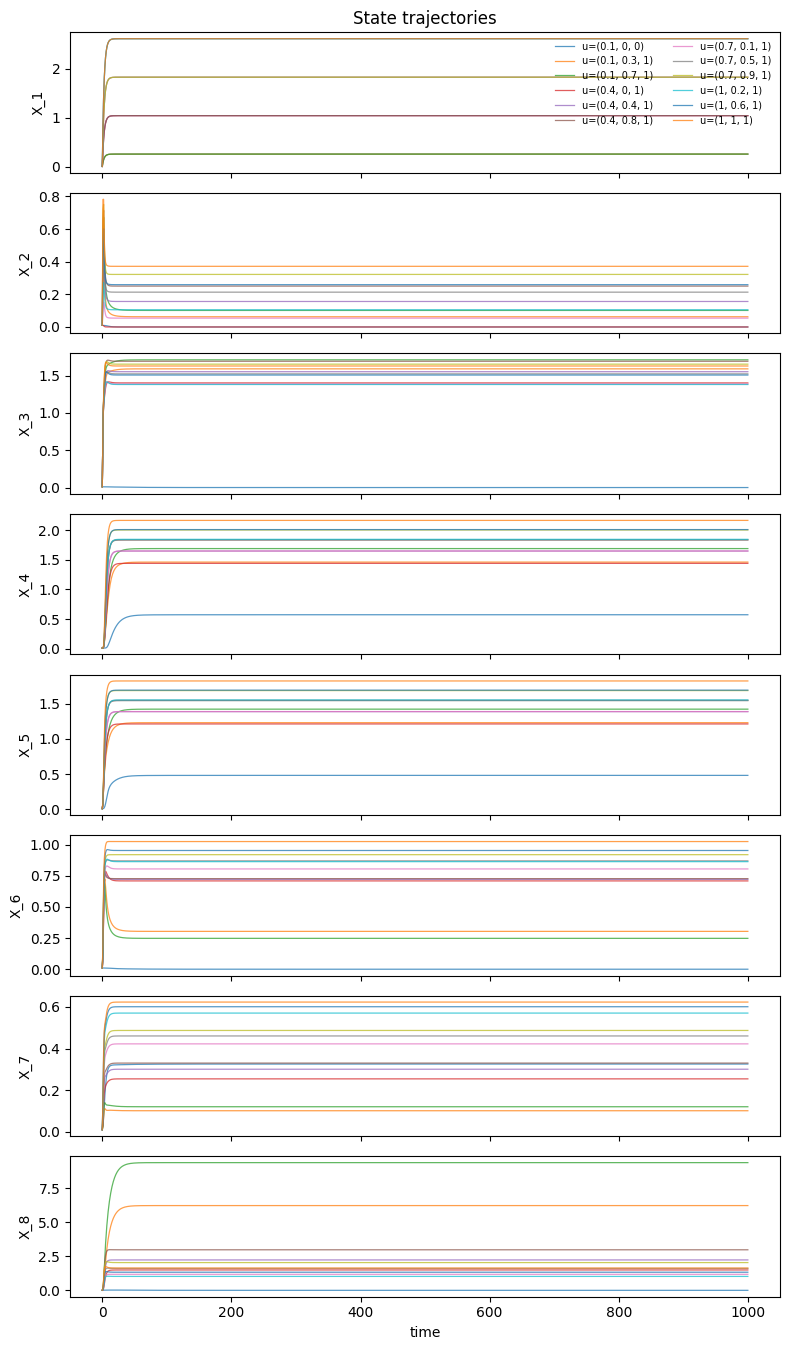

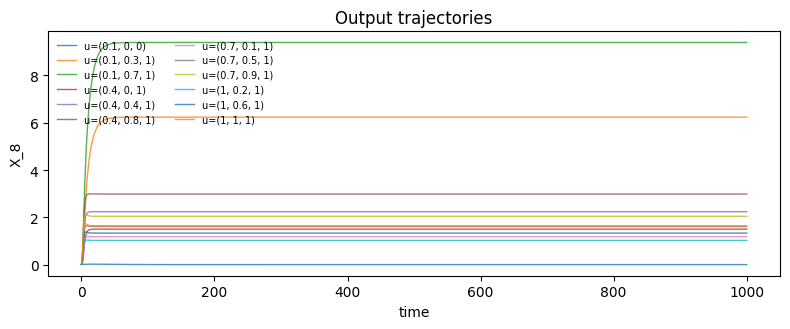

In [8]:
def _selected_trace_indices(n_traces, max_traces=12):
    if n_traces <= max_traces:
        return np.arange(n_traces, dtype=int)
    return np.unique(np.linspace(0, n_traces - 1, max_traces, dtype=int))


def plot_state_trajectories(time, states, u_list, *, species_labels=None, max_traces=12):
    trace_indices = _selected_trace_indices(len(states), max_traces=max_traces)
    n_species = np.asarray(states[0]).shape[0]

    if species_labels is None:
        species_labels = [f"X_{i + 1}" for i in range(n_species)]

    fig, axes = plt.subplots(n_species, 1, figsize=(8.0, 1.7 * n_species), sharex=True)
    axes = np.atleast_1d(axes)

    for idx in trace_indices:
        u = np.asarray(u_list[idx]).reshape(-1)
        label = f"u=({u[0]:.2g}, {u[1]:.2g}, {u[2]:.2g})"
        x = np.asarray(states[idx])
        for s, ax in enumerate(axes):
            ax.plot(time, x[s, :], linewidth=0.9, alpha=0.75, label=label if s == 0 else None)
            ax.set_ylabel(species_labels[s])

    axes[0].set_title("State trajectories")
    axes[0].legend(frameon=False, fontsize=7, ncol=2, loc="upper right")
    axes[-1].set_xlabel("time")
    fig.tight_layout()
    return fig, axes


def plot_output_trajectories(time, outputs, u_list, *, output_label="output", max_traces=12):
    trace_indices = _selected_trace_indices(len(outputs), max_traces=max_traces)

    fig, ax = plt.subplots(figsize=(8.0, 3.4))
    for idx in trace_indices:
        u = np.asarray(u_list[idx]).reshape(-1)
        label = f"u=({u[0]:.2g}, {u[1]:.2g}, {u[2]:.2g})"
        y = np.asarray(outputs[idx])
        ax.plot(time, y[0, :], linewidth=1.0, alpha=0.8, label=label)

    ax.set_title("Output trajectories")
    ax.set_xlabel("time")
    ax.set_ylabel(output_label)
    ax.legend(frameon=False, fontsize=7, ncol=2, loc="best")
    fig.tight_layout()
    return fig, ax


plot_state_trajectories(t_grid, x_grid, grid_inputs, species_labels=iocrn.species_labels, max_traces=12)
plot_output_trajectories(t_grid, y_grid, grid_inputs, output_label=iocrn.output_labels[0], max_traces=12)
plt.show()


## Parity Plot and Error Distributions


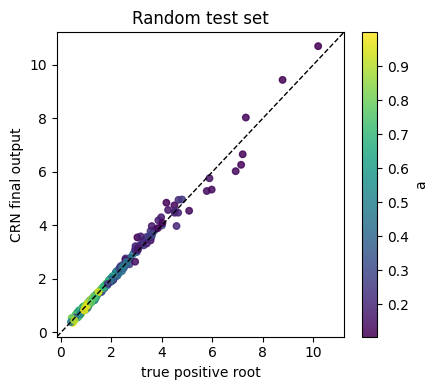

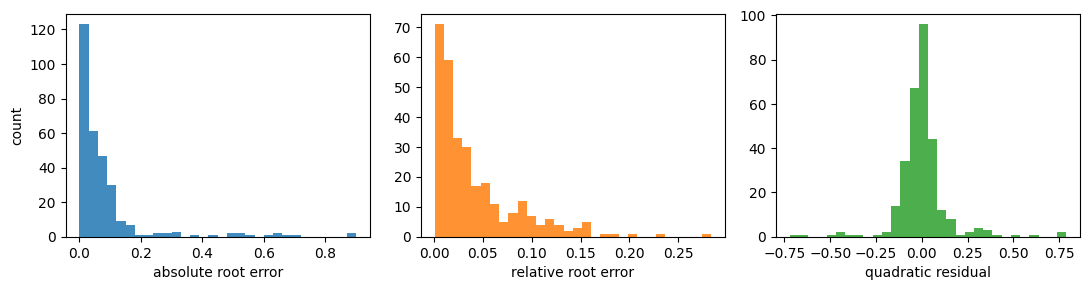

In [9]:
def plot_parity(df, color_by="abs_error", title="Predicted vs true root"):
    fig, ax = plt.subplots(figsize=(4.5, 4.0))
    sc = ax.scatter(df["x_true"], df["x_pred"], c=df[color_by], s=22, cmap="viridis", alpha=0.85)
    lo = min(df["x_true"].min(), df["x_pred"].min())
    hi = max(df["x_true"].max(), df["x_pred"].max())
    pad = 0.05 * max(hi - lo, 1e-12)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", linewidth=1.0)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel("true positive root")
    ax.set_ylabel("CRN final output")
    ax.set_title(title)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(color_by)
    fig.tight_layout()
    return fig, ax


def plot_error_histograms(df):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.0))
    axes[0].hist(df["abs_error"], bins=30, color="C0", alpha=0.85)
    axes[0].set_xlabel("absolute root error")
    axes[0].set_ylabel("count")
    axes[1].hist(df["rel_error"], bins=30, color="C1", alpha=0.85)
    axes[1].set_xlabel("relative root error")
    axes[2].hist(df["residual"], bins=30, color="C2", alpha=0.85)
    axes[2].set_xlabel("quadratic residual")
    fig.tight_layout()
    return fig, axes


fig_parity, ax_parity = plot_parity(df_random, color_by="a", title="Random test set")
fig_hist, axes_hist = plot_error_histograms(df_random)
fig_parity.savefig(
    "Parity_Quad_MA_8S_18R-11_Exp_2026-07-12.pdf",
    bbox_inches="tight",
)
fig_hist.savefig(
    "Hist_Quad_MA_8S_18R-11_Exp_2026-07-12.pdf",
    bbox_inches="tight",
)
plt.show()


## Error Heatmaps Over b and c at Fixed a

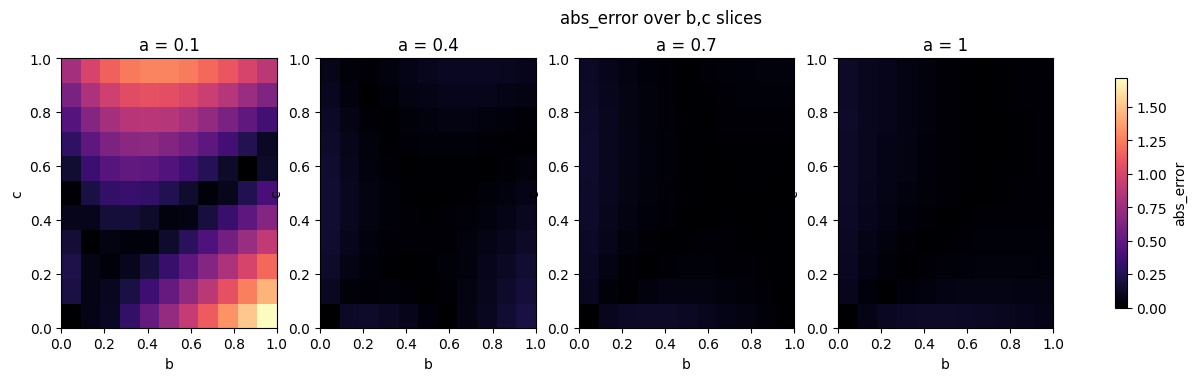

In [10]:
def plot_error_heatmaps(df, a_values_to_plot=None, value="abs_error"):
    if a_values_to_plot is None:
        a_values_to_plot = sorted(df["a"].unique())
    a_values_to_plot = list(a_values_to_plot)

    fig, axes = plt.subplots(1, len(a_values_to_plot), figsize=(4.0 * len(a_values_to_plot), 3.5), squeeze=False)
    vmax = df[value].max()

    for ax, a0 in zip(axes[0], a_values_to_plot):
        sub = df[np.isclose(df["a"], a0)].copy()
        table = sub.pivot(index="c", columns="b", values=value).sort_index(ascending=True)
        im = ax.imshow(
            table.values,
            origin="lower",
            aspect="auto",
            extent=[table.columns.min(), table.columns.max(), table.index.min(), table.index.max()],
            vmin=0.0,
            vmax=vmax,
            cmap="magma",
        )
        ax.set_title(f"a = {a0:g}")
        ax.set_xlabel("b")
        ax.set_ylabel("c")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label(value)
    fig.suptitle(f"{value} over b,c slices", y=1.02)
    return fig, axes


fig_heatmap, axes_heatmap = plot_error_heatmaps(df_grid, a_values_to_plot=a_values, value="abs_error")
fig_heatmap.savefig(
    "Heatmap_Quad_MA_8S_18R-11_Exp_2026-07-12.pdf",
    bbox_inches="tight",
)
plt.show()

## Line Slices

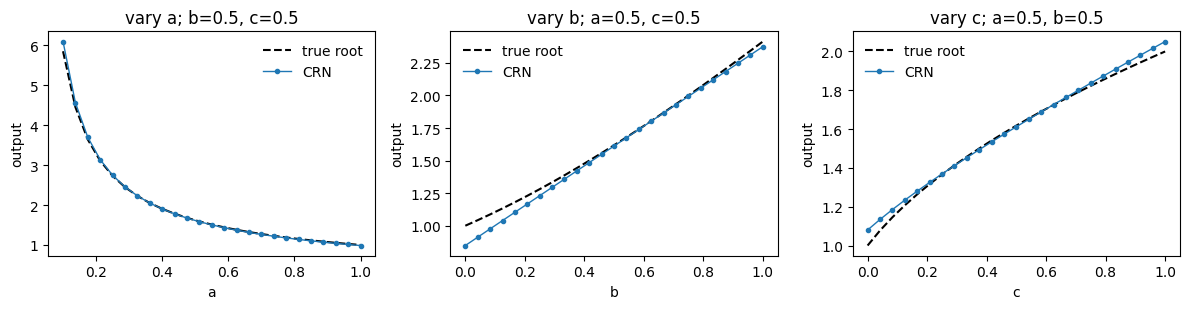

In [11]:
def evaluate_line_slice(crn, varying, values, fixed, *, t_f=100.0, n_t=1000, ic_value=0.01):
    order = ["a", "b", "c"]
    u_list = []
    for val in values:
        row = dict(fixed)
        row[varying] = float(val)
        u_list.append(np.array([row[name] for name in order], dtype=np.float32))
    df, _, _, _ = evaluate_crn(crn, u_list, t_f=t_f, n_t=n_t, ic_value=ic_value)
    df[varying] = values
    return df


def plot_line_slices(crn):
    slices = [
        ("a", np.linspace(0.1, 1.0, 25), {"b": 0.5, "c": 0.5}),
        ("b", np.linspace(0.0, 1.0, 25), {"a": 0.5, "c": 0.5}),
        ("c", np.linspace(0.0, 1.0, 25), {"a": 0.5, "b": 0.5}),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
    for ax, (varying, values, fixed) in zip(axes, slices):
        df = evaluate_line_slice(crn, varying, values, fixed)
        ax.plot(values, df["x_true"], "k--", linewidth=1.5, label="true root")
        ax.plot(values, df["x_pred"], "o-", markersize=3.0, linewidth=1.0, label="CRN")
        fixed_text = ", ".join(f"{k}={v:g}" for k, v in fixed.items())
        ax.set_title(f"vary {varying}; {fixed_text}")
        ax.set_xlabel(varying)
        ax.set_ylabel("output")
        ax.legend(frameon=False)

    fig.tight_layout()
    return fig, axes


plot_line_slices(iocrn)
plt.show()

## Hall of Fame Topological Diversity  

Found 30 unique topologies from 30 samples.
Performance data aggregated (Min Loss per topology).
Computing layout (spring)...
Dual Coloring: Face=Loss (Greyscale), Edge=Cluster (Rainbow) with Black Separator


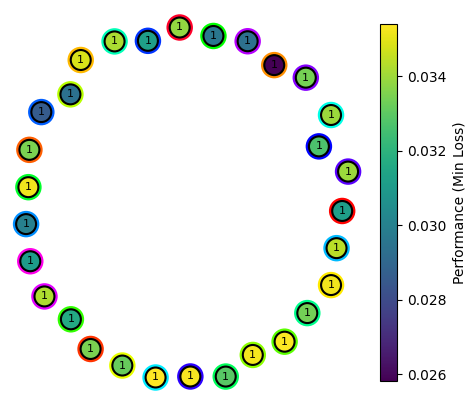

In [ ]:
from RL4CRN.utils.visualizations import visualize_crn_diversity

hof_losses = np.asarray([
    crn.last_task_info.get("reward", np.nan)
    for crn in hof
], dtype=float)

fig_topology = visualize_crn_diversity(
    hof,
    perf=hof_losses,
    k=None,
    t=5,
    alpha=0.0,
    unique=False,
    layout_method="spring",
    label_percentile=80,
    figsize=(5, 5),
    graph_dic={
        "fontsize": 8,
        "edgewidth": 0.8,
        "nodesize_multiplier": 300,
        "nodesize_offset": 50,
        "show_colorbar": True,
        "innersize_ratio": 0.8,
        "inner_node_linewidth": 1.5,
        "outer_node_linewidth": 3.0,
        "print_labels": True,
    },
)

if fig_topology is not None:
    fig_topology.suptitle("Hall of Fame Topological Diversity", y=0.98)

fig_topology.savefig(
    "TDG_Hab_MA_8S_18R-11_Exp_2026-07-dfasdf.pdf", 
    bbox_inches="tight",
)

## Reactant-Product Reaction Scatter

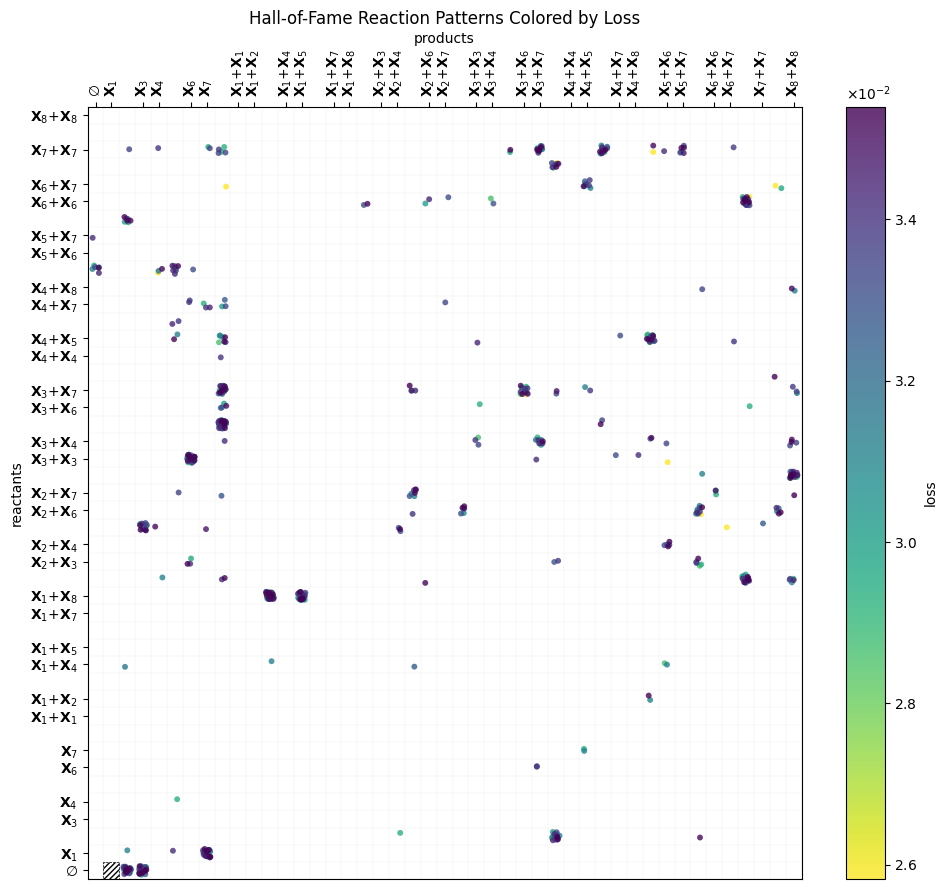

In [13]:
from RL4CRN.utils.visualizations import plot_reactant_product_scatter

hof_losses = np.asarray([
    crn.last_task_info.get("reward", np.nan)
    for crn in hof
], dtype=float)

fig_reaction_scatter = plot_reactant_product_scatter(
    hof,
    perf=hof_losses,
    species_labels=iocrn.species_labels,
    max_order=2,
    num_reactions_template=1,
    title="Hall-of-Fame Reaction Patterns Colored by Loss",
    cmap_name="viridis_r",
    max_ticks=30,
    figsize=(10, 9),
    jitter_scale=0.25,
    marker_size=18,
)